# ResNet18 — BatchNorm Tuning
Freeze backbone; train BatchNorm γ/β params + final FC head.

In [1]:
import os

os.chdir("..")  
print(os.getcwd())
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision.models import ResNet18_Weights

from helpers import (
    get_food101_loaders, run_training, plot_results, count_trainable_params
)

/Users/peter/Documents/MDS_UBC/DATA_586/food_classification


In [2]:
weights   = ResNet18_Weights.DEFAULT
transform = weights.transforms()

train_loader, val_loader = get_food101_loaders(transform, batch_size=256, num_workers=8)

In [3]:
model = models.resnet18(weights=weights)

# 1. Freeze everything
for param in model.parameters():
    param.requires_grad = False

# 2. Replace & unfreeze head
model.fc = nn.Linear(model.fc.in_features, 101)
for param in model.fc.parameters():
    param.requires_grad = True

# 3. Unfreeze BatchNorm γ / β
for m in model.modules():
    if isinstance(m, nn.BatchNorm2d):
        for param in m.parameters():
            param.requires_grad = True

print(f"Trainable params: {count_trainable_params(model):,}")

Trainable params: 61,413


In [4]:
model, train_losses, val_losses, train_accs, val_accs = run_training(
    model=model,
    model_name="resnet18_batch_norm",
    train_dataloader=train_loader,
    val_dataloader=val_loader,
    epochs=8,
    lr=1e-3,
)

[resnet18_batch_norm] Final checkpoint found — loading metrics for plotting.


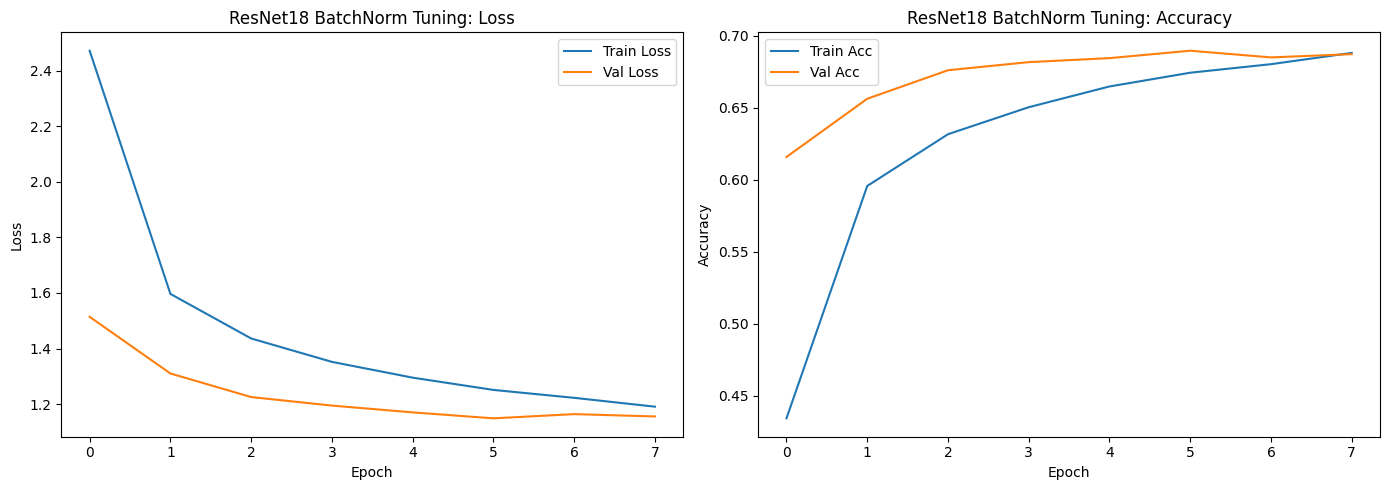

In [5]:
plot_results(train_losses, val_losses, train_accs, val_accs, "ResNet18 BatchNorm Tuning")